<a href="https://colab.research.google.com/github/coderpalak3109-cyber/Product_Demand_Prediction/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================
# DATA COLLECTION
# ==========================

import pandas as pd
import numpy as np

# Load datasets
train = pd.read_csv('train.csv')
meal = pd.read_csv('meal_info.csv')
center = pd.read_csv('fulfilment_center_info.csv')

# Display first few rows
print("TRAIN DATA")
print(train.head())

print("\nMEAL DATA")
print(meal.head())

print("\nCENTER DATA")
print(center.head())

# Merge datasets
df = train.merge(meal, on='meal_id')
df = df.merge(center, on='center_id')

# Dataset overview
print("\nMerged Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# Display final merged dataset
print("\nMerged Dataset Preview:")
print(df.head())

TRAIN DATA
        id  week  center_id  meal_id  checkout_price  base_price  \
0  1379560     1         55     1885          136.83      152.29   
1  1466964     1         55     1993          136.83      135.83   
2  1346989     1         55     2539          134.86      135.86   
3  1338232     1         55     2139          339.50      437.53   
4  1448490     1         55     2631          243.50      242.50   

   emailer_for_promotion  homepage_featured  num_orders  
0                      0                  0         177  
1                      0                  0         270  
2                      0                  0         189  
3                      0                  0          54  
4                      0                  0          40  

MEAL DATA
   meal_id   category cuisine
0     1885  Beverages    Thai
1     1993  Beverages    Thai
2     2539  Beverages    Thai
3     1248  Beverages  Indian
4     2631  Beverages  Indian

CENTER DATA
   center_id  city_code  reg

In [ ]:
# ==========================
# DATA PREPROCESSING
# ==========================

import pandas as pd
import numpy as np

# Check dataset shape
print("Dataset Shape:")
print(df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Target variable statistics
print("\nTarget Variable Statistics:")
print(df['num_orders'].describe())

# Check skewness of target
print("\nOriginal Skewness:")
print(df['num_orders'].skew())

# Log transformation
df['log_orders'] = np.log1p(df['num_orders'])

# Check skewness after transformation
print("\nSkewness After Log Transformation:")
print(df['log_orders'].skew())

# Feature Engineering

# Discount Percentage
df['discount_pct'] = (
    (df['base_price'] - df['checkout_price'])
    / df['base_price']
)

# Price Ratio
df['price_ratio'] = (
    df['checkout_price']
    / df['base_price']
)

# Encode categorical variables
df = pd.get_dummies(
    df,
    columns=['category', 'cuisine', 'center_type'],
    drop_first=True
)

# Drop unnecessary columns
df.drop(
    ['id', 'meal_id', 'center_id'],
    axis=1,
    inplace=True
)

# Final dataset information
print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Preview:")
print(df.head())

print("\nFinal Missing Values Check:")
print(df.isnull().sum().sum())

Dataset Shape:
(456548, 15)

Data Types:
id                         int64
week                       int64
center_id                  int64
meal_id                    int64
checkout_price           float64
base_price               float64
emailer_for_promotion      int64
homepage_featured          int64
num_orders                 int64
category                  object
cuisine                   object
city_code                  int64
region_code                int64
center_type               object
op_area                  float64
dtype: object

Missing Values:
id                       0
week                     0
center_id                0
meal_id                  0
checkout_price           0
base_price               0
emailer_for_promotion    0
homepage_featured        0
num_orders               0
category                 0
cuisine                  0
city_code                0
region_code              0
center_type              0
op_area                  0
dtype: int64

Duplicate Rows

In [ ]:
# ==========================
# FEATURE SELECTION
# ==========================

from sklearn.model_selection import train_test_split

# Input Features
X = df.drop(
    ['num_orders', 'log_orders'],
    axis=1
)

# Target Variable
y = df['log_orders']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

# ==========================
# MODEL FITTING
# ==========================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("\nModel Training Completed!")

# ==========================
# PREDICTIONS
# ==========================

y_pred = rf_model.predict(X_test)

# ==========================
# MODEL EVALUATION
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nModel Performance")

print("MAE :", mae)

print("RMSE :", rmse)

print("R² Score :", r2)

# ==========================
# FEATURE IMPORTANCE
# ==========================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 10 Important Features")

print(feature_importance.head(10))

Feature Matrix Shape: (456548, 28)
Target Shape: (456548,)

Training Data Shape:
(365238, 28)

Testing Data Shape:
(91310, 28)

Model Training Completed!

Model Performance
MAE : 0.4129954362963622
RMSE : 0.5387776541351055
R² Score : 0.7998387119432581

Top 10 Important Features
                  Feature  Importance
1          checkout_price    0.225096
2              base_price    0.104068
17     category_Rice Bowl    0.093567
0                    week    0.084943
7                 op_area    0.084784
24        cuisine_Italian    0.047453
3   emailer_for_promotion    0.045763
8            discount_pct    0.035770
5               city_code    0.033061
25           cuisine_Thai    0.031297


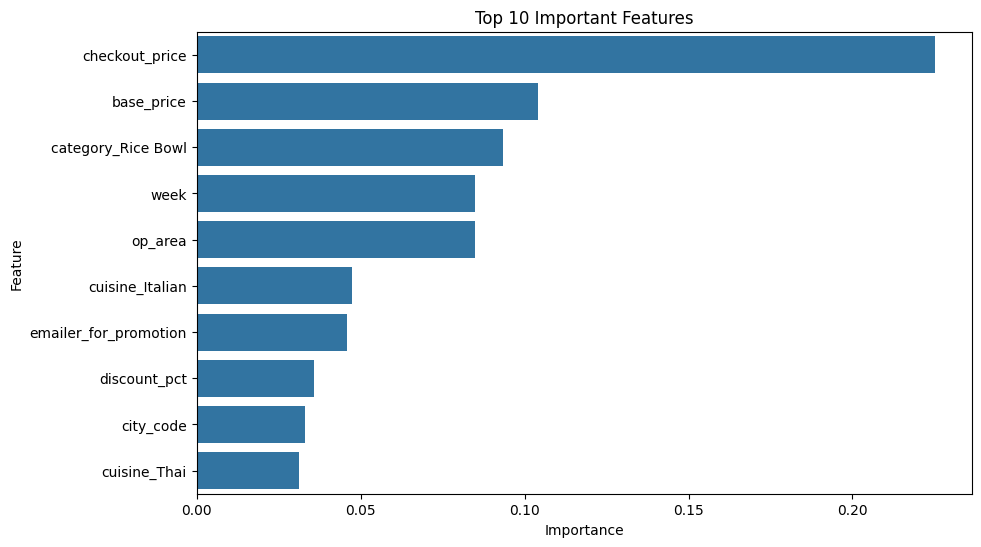

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 Feature Importance

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)
plt.title('Top 10 Important Features')
plt.show()

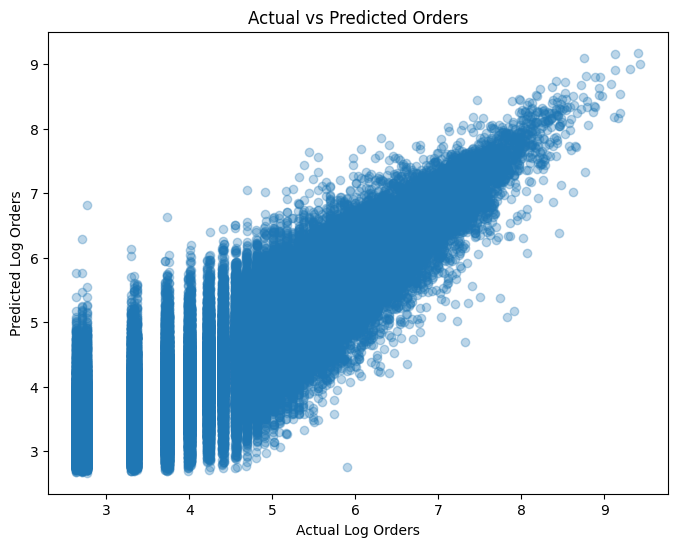

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Log Orders')
plt.ylabel('Predicted Log Orders')
plt.title('Actual vs Predicted Orders')
plt.show()

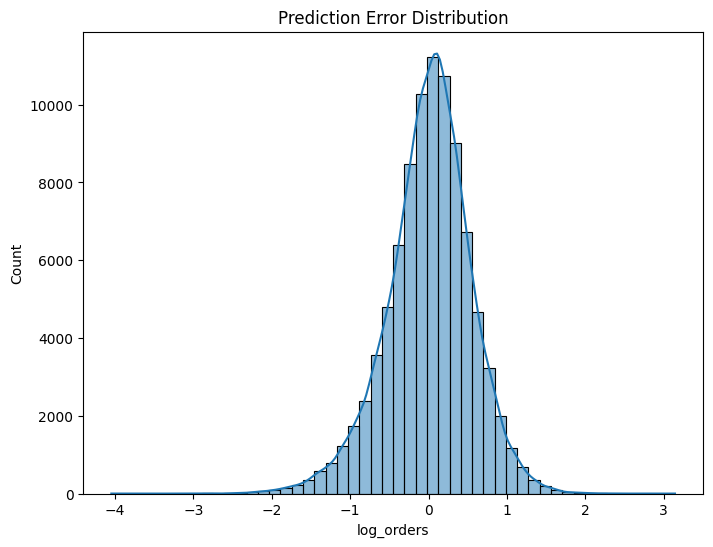

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(
    y_test - y_pred,
    bins=50,
    kde=True
)
plt.title('Prediction Error Distribution')
plt.show()

In [ ]:
# ==========================================
# EXPORT FILES FOR POWER BI DASHBOARD
# ==========================================

import pandas as pd
import os

# ------------------------------------------
# 1. Feature Importance CSV
# ------------------------------------------

feature_importance.to_csv(
    'feature_importance.csv',
    index=False
)

print("✓ feature_importance.csv created")


# ------------------------------------------
# 2. Prediction Results CSV
# ------------------------------------------

results_df = pd.DataFrame({
    'Actual_Log_Orders': y_test,
    'Predicted_Log_Orders': y_pred
})

results_df.to_csv(
    'food_demand_predictions.csv',
    index=False
)

print("✓ food_demand_predictions.csv created")


# ------------------------------------------
# 3. Final Processed Dataset CSV
# ------------------------------------------

df.to_csv(
    'food_demand_final.csv',
    index=False
)

print("✓ food_demand_final.csv created")


# ------------------------------------------
# 4. Verify Files
# ------------------------------------------

print("\nGenerated Files:")

files = [
    'feature_importance.csv',
    'food_demand_predictions.csv',
    'food_demand_final.csv'
]

for file in files:
    if os.path.exists(file):
        print(f"✓ {file}")
    else:
        print(f"✗ {file} not found")


# ------------------------------------------
# 5. Preview Data
# ------------------------------------------

print("\nFeature Importance Preview:")
print(feature_importance.head())

print("\nPrediction Results Preview:")
print(results_df.head())

print("\nFinal Dataset Shape:")
print(df.shape)

✓ feature_importance.csv created
✓ food_demand_predictions.csv created
✓ food_demand_final.csv created

Generated Files:
✓ feature_importance.csv
✓ food_demand_predictions.csv
✓ food_demand_final.csv

Feature Importance Preview:
               Feature  Importance
1       checkout_price    0.225096
2           base_price    0.104068
17  category_Rice Bowl    0.093567
0                 week    0.084943
7              op_area    0.084784

Prediction Results Preview:
        Actual_Log_Orders  Predicted_Log_Orders
203536           3.367296              4.136336
301801           5.176150              5.211192
254032           5.971262              5.070350
339158           2.708050              3.576549
3203             6.006353              6.590215

Final Dataset Shape:
(456548, 30)
